# Banking on Behaviour - Starter Notebook

This notebook shows you how to load the data and create a valid submission.

Feature engineering, model selection, and validation strategy are up to you.

**Target:** Predict `next_3m_txn_count` for each customer in Test.csv

**Metric:** RMSLE (Root Mean Squared Logarithmic Error)

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Core files
train = pd.read_csv('../data/raw/Train.csv')
test  = pd.read_csv('../data/raw/Test.csv')

print(f'Train: {train.shape}, Test: {test.shape}')
train.head()

Train: (8360, 2), Test: (3584, 1)


,UniqueID,next_3m_txn_count
0,00093e2d-9e1e-4061-ad27-a79b8ff9e165,129
1,0011d60f-a4e2-4333-81fc-2d557a82109b,16
2,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,117
3,001aa3c5-632d-435e-a421-cc3615ccef4d,70
4,00298c6f-4f9d-4f28-b72c-ad0e56e9eb84,393


<Axes: >

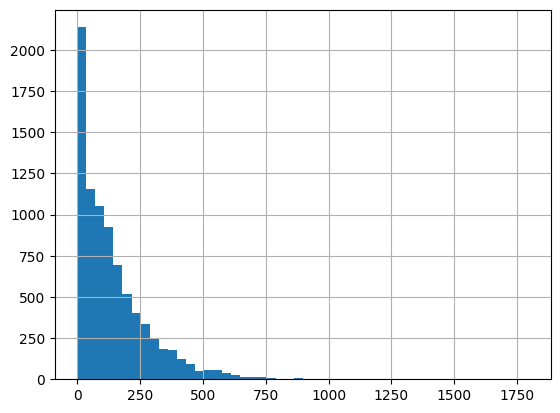

In [2]:
#Understanding the target
train['next_3m_txn_count'].describe()

#checking for missing values
train.isnull().sum() #no missing values

#analysing the skewness of the target variable
train['next_3m_txn_count'].hist(bins=50)

## 2. Transaction Features


In [3]:
# Load transactions
txn = pd.read_parquet('../data/raw/transactions_features.parquet')
txn['TransactionDate'] = pd.to_datetime(txn['TransactionDate'])
max_date = txn['TransactionDate'].max()
print(f'Transactions: {len(txn):,} rows | Date range: {txn["TransactionDate"].min()} to {max_date}')
print(txn.columns.tolist())

Transactions: 18,017,073 rows | Date range: 2012-12-25 00:00:00 to 2015-10-31 00:00:00
['UniqueID', 'AccountID', 'TransactionDate', 'TransactionAmount', 'TransactionTypeDescription', 'TransactionBatchDescription', 'StatementBalance', 'IsDebitCredit', 'ReversalTypeDescription']


In [4]:
# ============================================================
# FEATURE BLOCK 1: Overall transaction stats (all time)
# ============================================================
feat_all = txn.groupby('UniqueID').agg(
    txn_count_all   = ('TransactionAmount', 'count'),
    txn_sum_all     = ('TransactionAmount', 'sum'),
    txn_mean_all    = ('TransactionAmount', 'mean'),
    txn_std_all     = ('TransactionAmount', 'std'),
    txn_median_all  = ('TransactionAmount', 'median'),
).reset_index()

# ============================================================
# FEATURE BLOCK 2: Debit vs Credit split
# ============================================================
# The competition notes: TransactionAmount is signed — negatives = debits, positives = credits
debits  = txn[txn['TransactionAmount'] < 0]
credits = txn[txn['TransactionAmount'] > 0]

feat_debit = debits.groupby('UniqueID').agg(
    debit_count = ('TransactionAmount', 'count'),
    debit_sum   = ('TransactionAmount', 'sum'),
    debit_mean  = ('TransactionAmount', 'mean'),
).reset_index()

feat_credit = credits.groupby('UniqueID').agg(
    credit_count = ('TransactionAmount', 'count'),
    credit_sum   = ('TransactionAmount', 'sum'),
    credit_mean  = ('TransactionAmount', 'mean'),
).reset_index()

print('Debit/credit features built')

Debit/credit features built


In [5]:
# ============================================================
# FEATURE BLOCK 3: Recency windows (6m, 3m, 1m)
# ============================================================
def window_features(df, days, suffix):
    cutoff = max_date - pd.Timedelta(days=days)
    sub = df[df['TransactionDate'] >= cutoff]
    feat = sub.groupby('UniqueID').agg(
        count = ('TransactionAmount', 'count'),
        sum   = ('TransactionAmount', 'sum'),
        mean  = ('TransactionAmount', 'mean'),
    ).reset_index()
    feat.columns = ['UniqueID', f'txn_count_{suffix}', f'txn_sum_{suffix}', f'txn_mean_{suffix}']
    return feat

feat_6m = window_features(txn, 180, '6m')
feat_3m = window_features(txn, 90,  '3m')
feat_1m = window_features(txn, 30,  '1m')

print('Recency window features built')

Recency window features built


In [6]:
# ============================================================
# FEATURE BLOCK 4: Holiday season activity
# The prediction window is Nov-Jan (South African holiday season!)
# Use prior year Nov-Jan as a proxy
# ============================================================
holiday_mask = txn['TransactionDate'].dt.month.isin([11, 12, 1])
txn_holiday = txn[holiday_mask]

feat_holiday = txn_holiday.groupby('UniqueID').agg(
    holiday_txn_count = ('TransactionAmount', 'count'),
    holiday_txn_sum   = ('TransactionAmount', 'sum'),
    holiday_txn_mean  = ('TransactionAmount', 'mean'),
).reset_index()

print('Holiday season features built')

Holiday season features built


In [7]:
# ============================================================
# FEATURE BLOCK 5: Trend (are they transacting more or less recently?)
# Compare last 3m vs prior 3m (3-6m ago)
# ============================================================
cutoff_3m = max_date - pd.Timedelta(days=90)
cutoff_6m = max_date - pd.Timedelta(days=180)

recent    = txn[txn['TransactionDate'] >= cutoff_3m].groupby('UniqueID')['TransactionAmount'].count().rename('cnt_recent')
prior     = txn[(txn['TransactionDate'] >= cutoff_6m) & (txn['TransactionDate'] < cutoff_3m)].groupby('UniqueID')['TransactionAmount'].count().rename('cnt_prior')

trend_df = pd.concat([recent, prior], axis=1).reset_index()
trend_df = trend_df.fillna(0)
# Ratio > 1 means accelerating, < 1 means slowing down
trend_df['txn_trend_ratio'] = (trend_df['cnt_recent'] + 1) / (trend_df['cnt_prior'] + 1)
trend_df['txn_trend_diff']  = trend_df['cnt_recent'] - trend_df['cnt_prior']
trend_df = trend_df[['UniqueID', 'txn_trend_ratio', 'txn_trend_diff']]

print('Trend features built')

Trend features built


In [8]:
# ============================================================
# FEATURE BLOCK 6: Recency (days since last transaction)
# ============================================================
last_txn = txn.groupby('UniqueID')['TransactionDate'].max().reset_index()
last_txn.columns = ['UniqueID', 'last_txn_date']
last_txn['days_since_last_txn'] = (max_date - last_txn['last_txn_date']).dt.days
last_txn = last_txn[['UniqueID', 'days_since_last_txn']]

# Also first transaction (customer tenure)
first_txn = txn.groupby('UniqueID')['TransactionDate'].min().reset_index()
first_txn.columns = ['UniqueID', 'first_txn_date']
first_txn['customer_tenure_days'] = (max_date - first_txn['first_txn_date']).dt.days
first_txn = first_txn[['UniqueID', 'customer_tenure_days']]

print('Recency/tenure features built')

Recency/tenure features built


In [9]:
# ============================================================
# FEATURE BLOCK 7: Transaction type diversity
# ============================================================
if 'TransactionType' in txn.columns:
    type_div = txn.groupby('UniqueID')['TransactionType'].nunique().reset_index()
    type_div.columns = ['UniqueID', 'txn_type_diversity']
    print('Transaction type diversity features built')
else:
    print('No TransactionType column — skipping')
    type_div = None

# Monthly active months (how consistent is this customer?)
txn['year_month'] = txn['TransactionDate'].dt.to_period('M')
active_months = txn.groupby('UniqueID')['year_month'].nunique().reset_index()
active_months.columns = ['UniqueID', 'active_months']

# Average transactions per active month
avg_per_month = feat_all[['UniqueID', 'txn_count_all']].merge(active_months, on='UniqueID')
avg_per_month['avg_txn_per_month'] = avg_per_month['txn_count_all'] / avg_per_month['active_months']
avg_per_month = avg_per_month[['UniqueID', 'avg_txn_per_month']]

print('Diversity/consistency features built')

No TransactionType column — skipping
Diversity/consistency features built


## Financial Features




In [10]:
fin = pd.read_parquet('../data/raw/financials_features.parquet')
fin['RunDate'] = pd.to_datetime(fin['RunDate'])
max_fin_date = fin['RunDate'].max()
print(f'Financials: {len(fin):,} rows | Date range: {fin["RunDate"].min()} to {max_fin_date}')
print(fin.columns.tolist())

Financials: 372,245 rows | Date range: 2013-12-25 00:00:00 to 2015-10-31 00:00:00
['UniqueID', 'AccountID', 'RunDate', 'Product', 'NetInterestIncome', 'NetInterestRevenue']


In [11]:
# All-time financial aggregates
fin_all = fin.groupby('UniqueID').agg(
    avg_income   = ('NetInterestIncome', 'mean'),
    total_income = ('NetInterestIncome', 'sum'),
    std_income   = ('NetInterestIncome', 'std'),
    avg_revenue  = ('NetInterestRevenue', 'mean'),
    total_revenue= ('NetInterestRevenue', 'sum'),
    std_revenue  = ('NetInterestRevenue', 'std'),
).reset_index()

# Recent 6-month financial activity
fin_recent_cutoff = max_fin_date - pd.DateOffset(months=6)
fin_recent = fin[fin['RunDate'] >= fin_recent_cutoff].groupby('UniqueID').agg(
    recent_avg_income  = ('NetInterestIncome', 'mean'),
    recent_avg_revenue = ('NetInterestRevenue', 'mean'),
).reset_index()

# Number of distinct products
product_count = fin.groupby('UniqueID')['Product'].nunique().reset_index(name='num_products')

fin_features = fin_all.merge(fin_recent, on='UniqueID', how='left').merge(product_count, on='UniqueID', how='left')
print(f'Financial features: {fin_features.shape}')

Financial features: (11377, 10)


### 4. Demographics Features

In [12]:
demo = pd.read_parquet('../data/raw/demographics_clean.parquet')

# Clean noisy categories
demo = demo.replace(['None', 'Not Disclosed / Unknown', 'Other / Unclassified'], np.nan)

# Age feature
demo['BirthDate'] = pd.to_datetime(demo['BirthDate'], errors='coerce')
ref_date = pd.to_datetime('2015-10-01')  # Use dataset reference date, not today!
demo['age'] = (ref_date - demo['BirthDate']).dt.days // 365
demo.loc[(demo['age'] < 18) | (demo['age'] > 100), 'age'] = np.nan
demo['age'] = demo['age'].fillna(demo['age'].median())

# Collapse low-frequency cities
top_cities = demo['ResidentialCityName'].value_counts().nlargest(10).index
demo['ResidentialCityName'] = np.where(demo['ResidentialCityName'].isin(top_cities),
                                        demo['ResidentialCityName'], 'Other')

demo_selected = demo[['UniqueID', 'age', 'Gender', 'IncomeCategory',
                       'OccupationCategory', 'IndustryCategory',
                       'ResidentialCityName', 'CustomerBankingType']]

demo_ids = demo_selected[['UniqueID']]
demo_features_raw = demo_selected.drop(columns=['UniqueID'])
demo_encoded_features = pd.get_dummies(demo_features_raw, drop_first=True)
demo_encoded = pd.concat([demo_ids, demo_encoded_features], axis=1)
demo_encoded.columns = demo_encoded.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

print(f'Demo features: {demo_encoded.shape}')

Demo features: (11944, 51)


### 5. Merge All Features

In [13]:
def build_dataset(base_df):
    df = base_df.copy()
    
    # Transaction features
    df = df.merge(feat_all,     on='UniqueID', how='left')
    df = df.merge(feat_debit,   on='UniqueID', how='left')
    df = df.merge(feat_credit,  on='UniqueID', how='left')
    df = df.merge(feat_6m,      on='UniqueID', how='left')
    df = df.merge(feat_3m,      on='UniqueID', how='left')
    df = df.merge(feat_1m,      on='UniqueID', how='left')
    df = df.merge(feat_holiday,  on='UniqueID', how='left')
    df = df.merge(trend_df,     on='UniqueID', how='left')
    df = df.merge(last_txn,     on='UniqueID', how='left')
    df = df.merge(first_txn,    on='UniqueID', how='left')
    df = df.merge(active_months, on='UniqueID', how='left')
    df = df.merge(avg_per_month, on='UniqueID', how='left')
    if type_div is not None:
        df = df.merge(type_div, on='UniqueID', how='left')
    
    # Financial features
    df = df.merge(fin_features,  on='UniqueID', how='left')
    
    # Demographic features
    df = df.merge(demo_encoded,  on='UniqueID', how='left')
    
    # Derived ratio features
    df['debit_credit_ratio'] = (df.get('debit_count', 0) + 1) / (df.get('credit_count', 0) + 1)
    df['recent_activity_ratio'] = (df.get('txn_count_3m', 0) + 1) / (df.get('txn_count_6m', 0) + 1)
    
    df = df.fillna(0)
    return df

train_merged = build_dataset(train)
test_merged  = build_dataset(test)

print(f'Train features: {train_merged.shape}')
print(f'Test features:  {test_merged.shape}')

Train features: (8360, 92)
Test features:  (3584, 91)


### 6. Model training and Cross-Validation

In [14]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold

FEATURE_COLS = [c for c in train_merged.columns if c not in ['UniqueID', 'next_3m_txn_count']]

X = train_merged[FEATURE_COLS]
y = train_merged['next_3m_txn_count']
y_log = np.log1p(y)

X_test = test_merged[FEATURE_COLS]

print(f'Features: {len(FEATURE_COLS)}')
print(f'Training rows: {len(X)}')

Features: 90
Training rows: 8360


In [15]:
# ============================================================
# LightGBM with improved hyperparameters + early stopping
# ============================================================
lgbm_params = dict(
    n_estimators      = 2000,     # high — early stopping will find optimal
    learning_rate     = 0.02,
    num_leaves        = 63,       # more expressive than 50
    max_depth         = -1,
    min_child_samples = 15,
    subsample         = 0.8,
    subsample_freq    = 1,
    colsample_bytree  = 0.7,
    reg_alpha         = 0.1,      # L1 regularisation
    reg_lambda        = 0.1,      # L2 regularisation
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds    = np.zeros(len(X))
test_preds   = np.zeros(len(X_test))
rmsle_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val_raw = y_log.iloc[train_idx], y_log.iloc[val_idx]

    model = LGBMRegressor(**lgbm_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val_raw)],
        callbacks=[
            __import__('lightgbm').early_stopping(50, verbose=False),
            __import__('lightgbm').log_evaluation(period=-1)
        ]
    )

    val_pred_log = model.predict(X_val)
    oof_preds[val_idx] = val_pred_log
    test_preds += model.predict(X_test) / 5

    # RMSLE = RMSE on log1p space (since we predicted log1p(y))
    rmsle = np.sqrt(np.mean((val_pred_log - y_val_raw.values) ** 2))
    rmsle_scores.append(rmsle)
    print(f'Fold {fold+1} | best_iteration={model.best_iteration_} | RMSLE={rmsle:.4f}')

print(f'\nMean CV RMSLE: {np.mean(rmsle_scores):.4f} ± {np.std(rmsle_scores):.4f}')

Fold 1 | best_iteration=233 | RMSLE=0.3977
Fold 2 | best_iteration=280 | RMSLE=0.3848
Fold 3 | best_iteration=218 | RMSLE=0.3901
Fold 4 | best_iteration=234 | RMSLE=0.3997
Fold 5 | best_iteration=213 | RMSLE=0.3538

Mean CV RMSLE: 0.3852 ± 0.0166


In [16]:
# Feature importance — spot what's actually driving predictions
fi = pd.DataFrame({'feature': FEATURE_COLS, 'importance': model.feature_importances_})
fi = fi.sort_values('importance', ascending=False)
print(fi.head(20).to_string(index=False))

              feature  importance
         txn_count_6m        1103
         txn_count_1m         805
         txn_count_3m         787
    avg_txn_per_month         591
    holiday_txn_count         542
      txn_trend_ratio         500
          debit_count         409
 customer_tenure_days         378
recent_activity_ratio         368
        txn_count_all         360
   debit_credit_ratio         359
         credit_count         355
                  age         346
           debit_mean         331
       txn_median_all         327
  days_since_last_txn         311
       txn_trend_diff         308
           std_income         301
          credit_mean         278
            debit_sum         268


## 4. Create a Valid Submission

Your submission must match the format of SampleSubmission.csv exactly.

In [17]:
# Convert log predictions back to raw counts
test_preds_raw = np.expm1(test_preds)
test_preds_raw = np.maximum(test_preds_raw, 0)

submission = pd.read_csv('../data/raw/SampleSubmission.csv')
submission['next_3m_txn_count'] = test_preds_raw
submission.to_csv('submission_v1.csv', index=False)
print(submission.head())

                               UniqueID  next_3m_txn_count
0  6b62ce75-9823-4de6-ba7b-8b2b199df239          20.579998
1  e193e600-a706-4bc6-8597-d5d6fb171ab5           4.491858
2  8fd44803-12ed-46ab-a146-8496d95d1b13          33.950320
3  12606376-113f-4c90-94b9-65f64f9fa8c7           4.218705
4  da070817-27ed-44b2-bc05-e817ea311519         243.077926


## Local Scoring

You can score your submission locally using the included evaluate.py script:



Note: PublicReference.csv is only available if you have it for local testing. On Zindi, scoring is automatic.